In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
data = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv")
data.to_csv("submission.csv",index=False)

In [3]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch

import warnings
warnings.filterwarnings("ignore")

In [25]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [ ]:
# CONFIGURATION
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES = [
    'blues', 'classical', 'country', 'disco', 'hiphop', 
    'jazz', 'metal', 'pop', 'reggae', 'rock'
]
STEMS = {
    'drums.wav': 'drums',
    'vocals.wav': 'vocals',
    'bass.wav': 'bass',
    'other.wav': 'other'
}
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0

In [ ]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEM_KEYS} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEM_KEYS} for g in GENRES}

    rng = random.Random(seed)
    
    # Tracking variables for Q1 & Q2
    corrupted_count = 0
    less_than_5_0491MB = 0
    greater_than_5_0493MB = 0
    
    # 1MB = 1024 * 1024 bytes
    threshold_low = 5.0491 * 1024 * 1024
    threshold_high = 5.0493 * 1024 * 1024

    for genre in GENRES:
        genre_path = os.path.join(root_dir, 'genres_stems', genre)
        if not os.path.exists(genre_path): continue
        
        # Get list of song folders
        songs = sorted([d for d in os.listdir(genre_path) if os.path.isdir(os.path.join(genre_path, d))])
        valid_songs = []

        for song in songs:
            song_path = os.path.join(genre_path, song)
            stems_present = True
            
            for s_key in STEM_KEYS:
                f_path = os.path.join(song_path, f"{s_key}.wav")
                if not os.path.exists(f_path):
                    stems_present = False
                    break
                
                f_size = os.path.getsize(f_path)
                if f_size < 4096: # 4kb
                    corrupted_count += 1
                    stems_present = False
                
                if f_size < threshold_low: less_than_5_0491MB += 1
                if f_size > threshold_high: greater_than_5_0493MB += 1
            
            if stems_present:
                valid_songs.append(song)

        # Shuffle and Split
        rng.shuffle(valid_songs)
        split_point = int(len(valid_songs) * (1 - val_split))
        tr_songs, val_songs = valid_songs[:split_point], valid_songs[split_point:]

        for s in tr_songs:
            for k in STEM_KEYS:
                train_dataset[genre][k].append(os.path.join(genre_path, s, f"{k}.wav"))
        for s in val_songs:
            for k in STEM_KEYS:
                val_dataset[genre][k].append(os.path.join(genre_path, s, f"{k}.wav"))

    print(f"Q1 Answer: {corrupted_count + less_than_5_0491MB}")
    print(f"Q2 Answer: {abs(greater_than_5_0493MB - less_than_5_0491MB)}")
    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)
print(f"Q3 Answer: {abs(len(tr['reggae']['drums']) - len(val['country']['vocals']))}")

In [ ]:
def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=TOP_DB):
    records = []
    for genre, stems in tqdm(dataset_dict.items()):
        for stem_name, file_paths in stems.items():
            for path in file_paths:
                y, _ = librosa.load(path, sr=sr)
                duration = librosa.get_duration(y=y, sr=sr)
                intervals = librosa.effects.split(y, top_db=top_db)
                
                max_silence = 0
                locs = []
                
                if len(intervals) == 0:
                    max_silence = duration
                    locs = ["full"]
                else:
                    # Check Start/End/Middle
                    start_gap = intervals[0][0] / sr
                    end_gap = (len(y) - intervals[-1][1]) / sr
                    
                    if start_gap >= threshold_sec: locs.append("start")
                    if end_gap >= threshold_sec: locs.append("end")
                    
                    max_silence = max(start_gap, end_gap)
                    
                    for i in range(len(intervals)-1):
                        mid_gap = (intervals[i+1][0] - intervals[i][1]) / sr
                        if mid_gap >= threshold_sec:
                            if "middle" not in locs: locs.append("middle")
                        max_silence = max(max_silence, mid_gap)

                if max_silence >= threshold_sec:
                    records.append({
                        "Genre": genre, "Stem": stem_name, "Max_Silence_Sec": max_silence,
                        "Silence_Location": " ".join(locs)
                    })
    return pd.DataFrame(records)

In [ ]:
df_silence = find_long_silences(tr, threshold_sec=5.0, top_db=TOP_DB)

q4_ans = len(df_silence)

vocals_df = df_silence[df_silence['Stem'] == 'vocals']
q5_ans = len(vocals_df)

q6_ans = vocals_df['Max_Silence_Sec'].mean() if not vocals_df.empty else 0

jazz_drums = df_silence[(df_silence['Genre'] == 'jazz') & (df_silence['Stem'] == 'drums')]
q7_ans = len(jazz_drums)

jazz_drums_mid_only = jazz_drums[jazz_drums['Silence_Location'].str.strip() == 'middle']
q8_ans = len(jazz_drums_mid_only)

jazz_drums_10s = jazz_drums[jazz_drums['Max_Silence_Sec'] >= 10]
q9_ans = len(jazz_drums_10s)

print(f"Answer Q4: {q4_ans}")
print(f"Answer Q5: {q5_ans}")
print(f"Answer Q6: {round(q6_ans, 2)}")
print(f"Answer Q7: {q7_ans}")
print(f"Answer Q8: {q8_ans}")
print(f"Answer Q9: {q9_ans}")

In [ ]:
# Select first rock song from 'tr'
rock_song_paths = [tr['rock'][k][SONG_INDEX] for k in STEM_KEYS]
stems_audio = [librosa.load(p, sr=SR, duration=DURATION)[0] for p in rock_song_paths]

stems_stack = np.array(stems_audio)
mix_raw = np.sum(stems_stack, axis=0)

rms_val = np.sqrt(np.mean(mix_raw**2))
max_val = np.max(np.abs(mix_raw))
mix_norm = mix_raw / max_val

print(f"Q10: {len(mix_raw)}")
print(f"Q11: {round(rms_val, 2)}")
print(f"Q12: {round(max_val, 2)}")

In [4]:
import librosa
import os

jazz_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/jazz/'
durations = []

for song_folder in os.listdir(jazz_path):
    # Path to one of the stems
    file_path = os.path.join(jazz_path, song_folder, 'drums.wav')
    if os.path.exists(file_path):
        durations.append(librosa.get_duration(path=file_path))

mean_duration = sum(durations) / len(durations)
print(f"Mean Jazz Duration: {mean_duration} seconds")

Mean Jazz Duration: 30.032979591836735 seconds


In [5]:
import os
import soundfile as sf
from tqdm import tqdm

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
folders_to_scan = ['genres_stems', 'ESC-50-master/audio', 'mashups']

def get_unique_sample_rates(root_path, target_folders):
    unique_rates = set()
    
    for folder in target_folders:
        full_path = os.path.join(root_path, folder)
        print(f"Scanning {folder}...")
        
        # Walk through all subdirectories and files
        for root, dirs, files in os.walk(full_path):
            for file in files:
                if file.endswith('.wav'):
                    file_path = os.path.join(root, file)
                    try:
                        # sf.info is much faster than librosa.load
                        info = sf.info(file_path)
                        unique_rates.add(info.samplerate)
                    except Exception as e:
                        print(f"Error reading {file}: {e}")
                        
    return sorted(list(unique_rates))

# Execution
rates = get_unique_sample_rates(DATA_ROOT, folders_to_scan)
print(f"\nUnique Sample Rates: {rates}")

Scanning genres_stems...
Scanning ESC-50-master/audio...
Scanning mashups...

Unique Sample Rates: [22050, 44100]


In [40]:
import os
from tqdm import tqdm

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

def count_empty_files(directory):
    empty_count = 0
    total_audio_files = 0
    
    # Walk through all genre folders and song subfolders
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.wav'):
                total_audio_files += 1
                file_path = os.path.join(root, file)
                
                # Check if file size is 0
                if os.path.getsize(file_path) == 0:
                    empty_count += 1
                    print(f"Empty file found: {file_path}")
                    
    return empty_count, total_audio_files

# Execution
empty_files, total_files = count_empty_files(DATA_ROOT)

print("-" * 30)
print(f"Total .wav files scanned: {total_files}")
print(f"Total empty (0-byte) files: {empty_files}")

------------------------------
Total .wav files scanned: 4000
Total empty (0-byte) files: 0


In [32]:
import os
import librosa
import numpy as np
from tqdm import tqdm

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

peak_values_db = []

for genre in genres:
    genre_path = os.path.join(DATA_ROOT, genre)
    song_folders = [d for d in os.listdir(genre_path) if os.path.isdir(os.path.join(genre_path, d))]
    
    for folder in song_folders:
        file_path = os.path.join(genre_path, folder, 'vocals.wav')
        
        if os.path.exists(file_path):
            # sr=None is faster as it skips resampling
            y, _ = librosa.load(file_path, sr=None)
            
            if len(y) > 0:
                # Find the peak absolute amplitude
                peak_amp = np.max(np.abs(y))
                
                if peak_amp > 1e-10: # Ignore absolute silence
                    # Convert to dB: 20 * log10(amplitude)
                    peak_db = 20 * np.log10(peak_amp)
                    peak_values_db.append(peak_db)

avg_peak_db = np.mean(peak_values_db)
print(f"Average Peak Amplitude: {avg_peak_db:.2f} dB")

Average Peak Amplitude: -12.49 dB


In [33]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
STEM_FILES = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']

def get_genre_centroid_stats(data_root, genres):
    genre_means = {}
    
    for genre in genres:
        print(f"Processing {genre}...")
        genre_path = os.path.join(data_root, genre)
        song_folders = [d for d in os.listdir(genre_path) if os.path.isdir(os.path.join(genre_path, d))]
        
        song_centroids = []
        
        # Processing a sample (or all) to find the mean
        for folder in tqdm(song_folders[:20]): # Using 20 songs per genre for a quick statistical estimate
            full_signal = None
            
            for stem in STEM_FILES:
                path = os.path.join(genre_path, folder, stem)
                if os.path.exists(path):
                    y, sr = librosa.load(path, sr=22050)
                    if full_signal is None:
                        full_signal = y
                    else:
                        # Ensure signals match in length before summing
                        min_len = min(len(full_signal), len(y))
                        full_signal = full_signal[:min_len] + y[:min_len]
            
            if full_signal is not None and np.max(np.abs(full_signal)) > 1e-4:
                # Calculate Spectral Centroid
                sc = librosa.feature.spectral_centroid(y=full_signal, sr=sr)[0]
                # Filter out silence/NaNs
                rms = librosa.feature.rms(y=full_signal)[0]
                valid_sc = sc[rms > 0.001]
                
                if len(valid_sc) > 0:
                    song_centroids.append(np.mean(valid_sc))
        
        genre_means[genre] = np.mean(song_centroids)
    
    return genre_means

# Execute and find the maximum
results = get_genre_centroid_stats(DATA_ROOT, GENRES)
brightest_genre = max(results, key=results.get)

print("\n--- Results ---")
for g, val in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{g.capitalize()}: {val:.2f} Hz")

print(f"\nWinner: {brightest_genre.upper()} has the highest mean spectral centroid.")

Processing blues...


100%|██████████| 20/20 [00:07<00:00,  2.68it/s]


Processing classical...


100%|██████████| 20/20 [00:08<00:00,  2.42it/s]


Processing country...


...

Processing reggae...


100%|██████████| 20/20 [00:09<00:00,  2.21it/s]


Processing rock...


100%|██████████| 20/20 [00:08<00:00,  2.24it/s]


--- Results ---
Pop: 2807.11 Hz
Metal: 2669.04 Hz
Disco: 2548.84 Hz
Hiphop: 2503.88 Hz
Rock: 2273.33 Hz
Reggae: 2114.06 Hz
Country: 2097.36 Hz
Blues: 1604.44 Hz
Jazz: 1595.70 Hz
Classical: 1379.15 Hz

Winner: POP has the highest mean spectral centroid.


In [35]:
import os
import librosa
import numpy as np
from tqdm import tqdm

DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
THRESHOLD = 1e-4
DURATION = 0.5  # seconds

silent_count = 0
total_files = 0

# Get all genre folders
genres = [d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))]

for genre in genres:
    genre_path = os.path.join(DATA_ROOT, genre)
    # Walk through song folders and stems
    for root, dirs, files in os.walk(genre_path):
        for file in files:
            if file.endswith('.wav'):
                total_files += 1
                file_path = os.path.join(root, file)
                
                try:
                    # Load only the first 0.5 seconds
                    y, sr = librosa.load(file_path, sr=None, duration=DURATION)
                    
                    if len(y) > 0:
                        # Check if peak amplitude is below threshold
                        if np.max(np.abs(y)) < THRESHOLD:
                            silent_count += 1
                except Exception as e:
                    continue

print(f"\nTotal Files Scanned: {total_files}")
print(f"Files with silent intro (< {DURATION}s): {silent_count}")
print(f"Percentage: {(silent_count/total_files)*100:.2f}%")


Total Files Scanned: 4000
Files with silent intro (< 0.5s): 333
Percentage: 8.33%


Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.43      0.30      0.35        10
   classical       0.00      0.00      0.00        10
     country       0.12      0.20      0.15        10
       disco       0.21      0.70      0.33        10
      hiphop       0.00      0.00      0.00        10
        jazz       0.08      0.10      0.09        10
       metal       0.38      0.30      0.33        10
         pop       0.00      0.00      0.00        10
      reggae       0.20      0.40      0.27        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.20       100
   macro avg       0.14      0.20      0.15       100
weighted avg       0.14      0.20      0.15       100



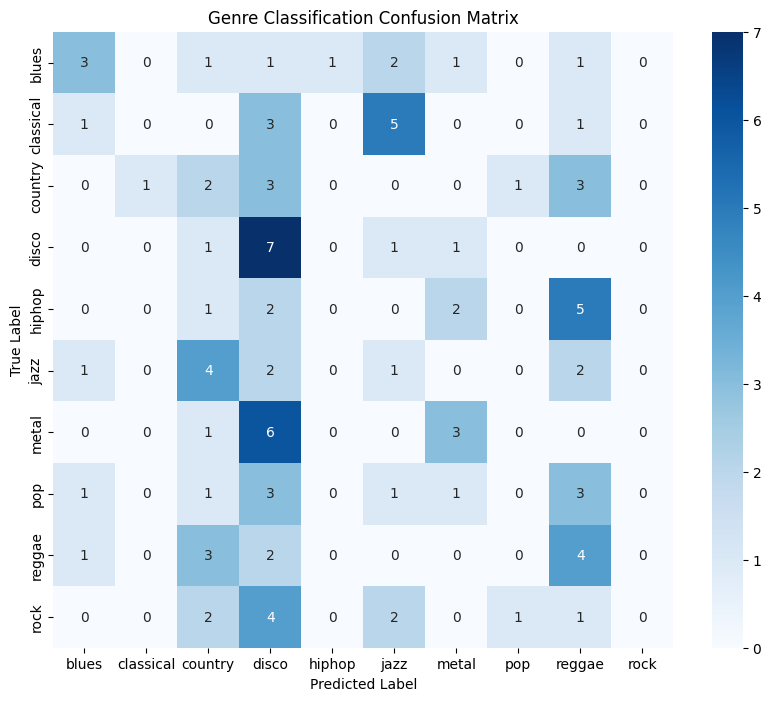


--- Answers to your questions ---
1. Validation macro F1 score: 0.1523
2. Precision of hiphop: 0.0000
3. Recall of pop: 0.0000
4. Model accuracy: 0.2000
5. Genre with the highest true positives: Disco (TP=7)
6. Genre with the lowest false negatives: Disco (FN=3)


In [41]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    
    # tempo is an array in newer librosa versions, so we extract the scalar
    tempo_val = float(tempo[0]) if isinstance(tempo, np.ndarray) else float(tempo)
    return [tempo_val, spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    # Note: os.listdir order is random. Sort it if you want reproducible subsets!
    songs = sorted([s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))])
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# --- 4. Validation & Metrics ---
y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred, labels=GENRES)
cr = classification_report(y_val, y_pred, target_names=GENRES)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

# --- 5. Visualizing CM and Computing TP, TN, FP, FN ---


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Genre Classification Confusion Matrix')
plt.show()

# Compute TP, TN, FP, FN across all classes
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - (fp + fn + tp)

print("\n--- Answers to your questions ---")
cr_dict = classification_report(y_val, y_pred, target_names=GENRES, output_dict=True)

print(f"1. Validation macro F1 score: {macro_f1:.4f}")
print(f"2. Precision of hiphop: {cr_dict['hiphop']['precision']:.4f}")
print(f"3. Recall of pop: {cr_dict['pop']['recall']:.4f}")
print(f"4. Model accuracy: {cr_dict['accuracy']:.4f}")

highest_tp_idx = np.argmax(tp)
lowest_fn_idx = np.argmin(fn)
print(f"5. Genre with the highest true positives: {GENRES[highest_tp_idx].capitalize()} (TP={tp[highest_tp_idx]})")
print(f"6. Genre with the lowest false negatives: {GENRES[lowest_fn_idx].capitalize()} (FN={fn[lowest_fn_idx]})")